PROBLEM STATEMENT :-
Student burnout is an increasing concern in academic environments, affecting performance, mental health, and overall productivity.

The objective of this project is to develop a machine learning classification system that predicts a student’s burnout level (Low, Medium, High) based on behavioral and academic features such as study hours, sleep duration, attendance percentage, assignment delays, screen time, physical activity, and CGPA.

By analyzing these factors, the system aims to:
	•	Identify high-risk students early
	•	Support data-driven academic intervention
	•	Compare multiple machine learning algorithms to determine the most effective predictive model

The final goal is to build a scalable prediction pipeline capable of handling new student inputs for real-time burnout risk assessment.

In [1]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\Priyanshu Kumar\Desktop\Student Burnout & Acedemic Risk Prediction System\data\raw\student_burnout_dataset_350.csv")
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours_per_day,attendance_percentage,assignment_delay_days,screen_time_hours,physical_activity_hours,cgpa,burnout_score,burnout_level
0,1,24,Female,5.7,8.8,63.4,5,6.2,1.4,6.24,15.26,Medium
1,2,21,Male,4.0,8.1,89.9,7,3.6,0.9,8.63,12.55,Medium
2,3,22,Male,2.5,8.4,65.5,1,6.9,1.4,7.07,7.75,Low
3,4,24,Female,4.7,5.9,72.8,2,4.4,1.8,7.46,12.15,Medium
4,5,20,Female,4.3,5.3,50.6,5,5.4,1.5,6.95,17.33,Medium


In [2]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               350 non-null    int64  
 1   age                      350 non-null    int64  
 2   gender                   350 non-null    object 
 3   study_hours_per_day      350 non-null    float64
 4   sleep_hours_per_day      350 non-null    float64
 5   attendance_percentage    350 non-null    float64
 6   assignment_delay_days    350 non-null    int64  
 7   screen_time_hours        350 non-null    float64
 8   physical_activity_hours  350 non-null    float64
 9   cgpa                     350 non-null    float64
 10  burnout_score            350 non-null    float64
 11  burnout_level            350 non-null    object 
dtypes: float64(7), int64(3), object(2)
memory usage: 32.9+ KB


student_id                 0
age                        0
gender                     0
study_hours_per_day        0
sleep_hours_per_day        0
attendance_percentage      0
assignment_delay_days      0
screen_time_hours          0
physical_activity_hours    0
cgpa                       0
burnout_score              0
burnout_level              0
dtype: int64

In [3]:
df = df.drop("student_id",axis=1)

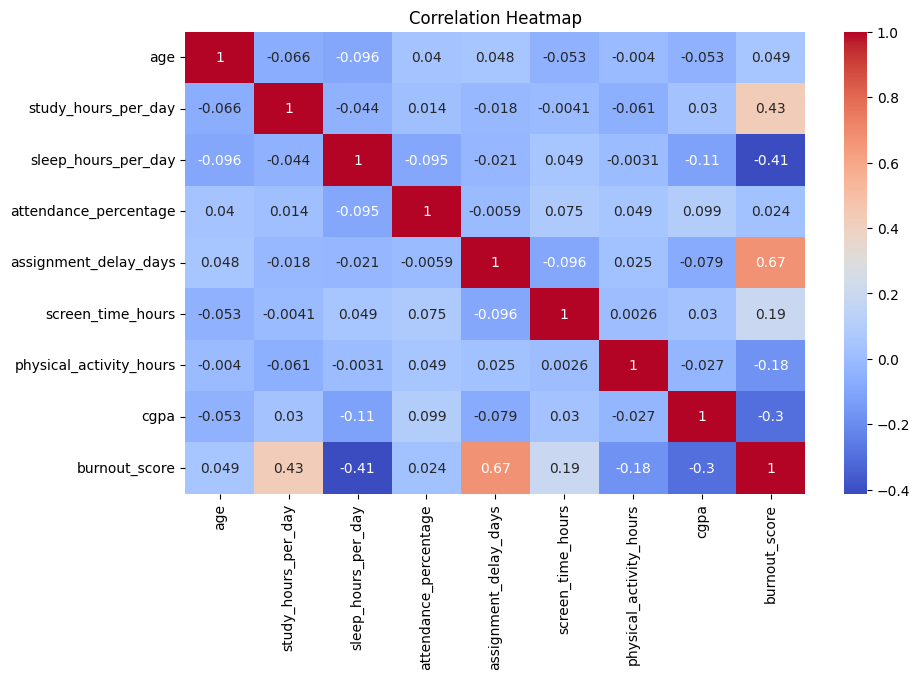

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

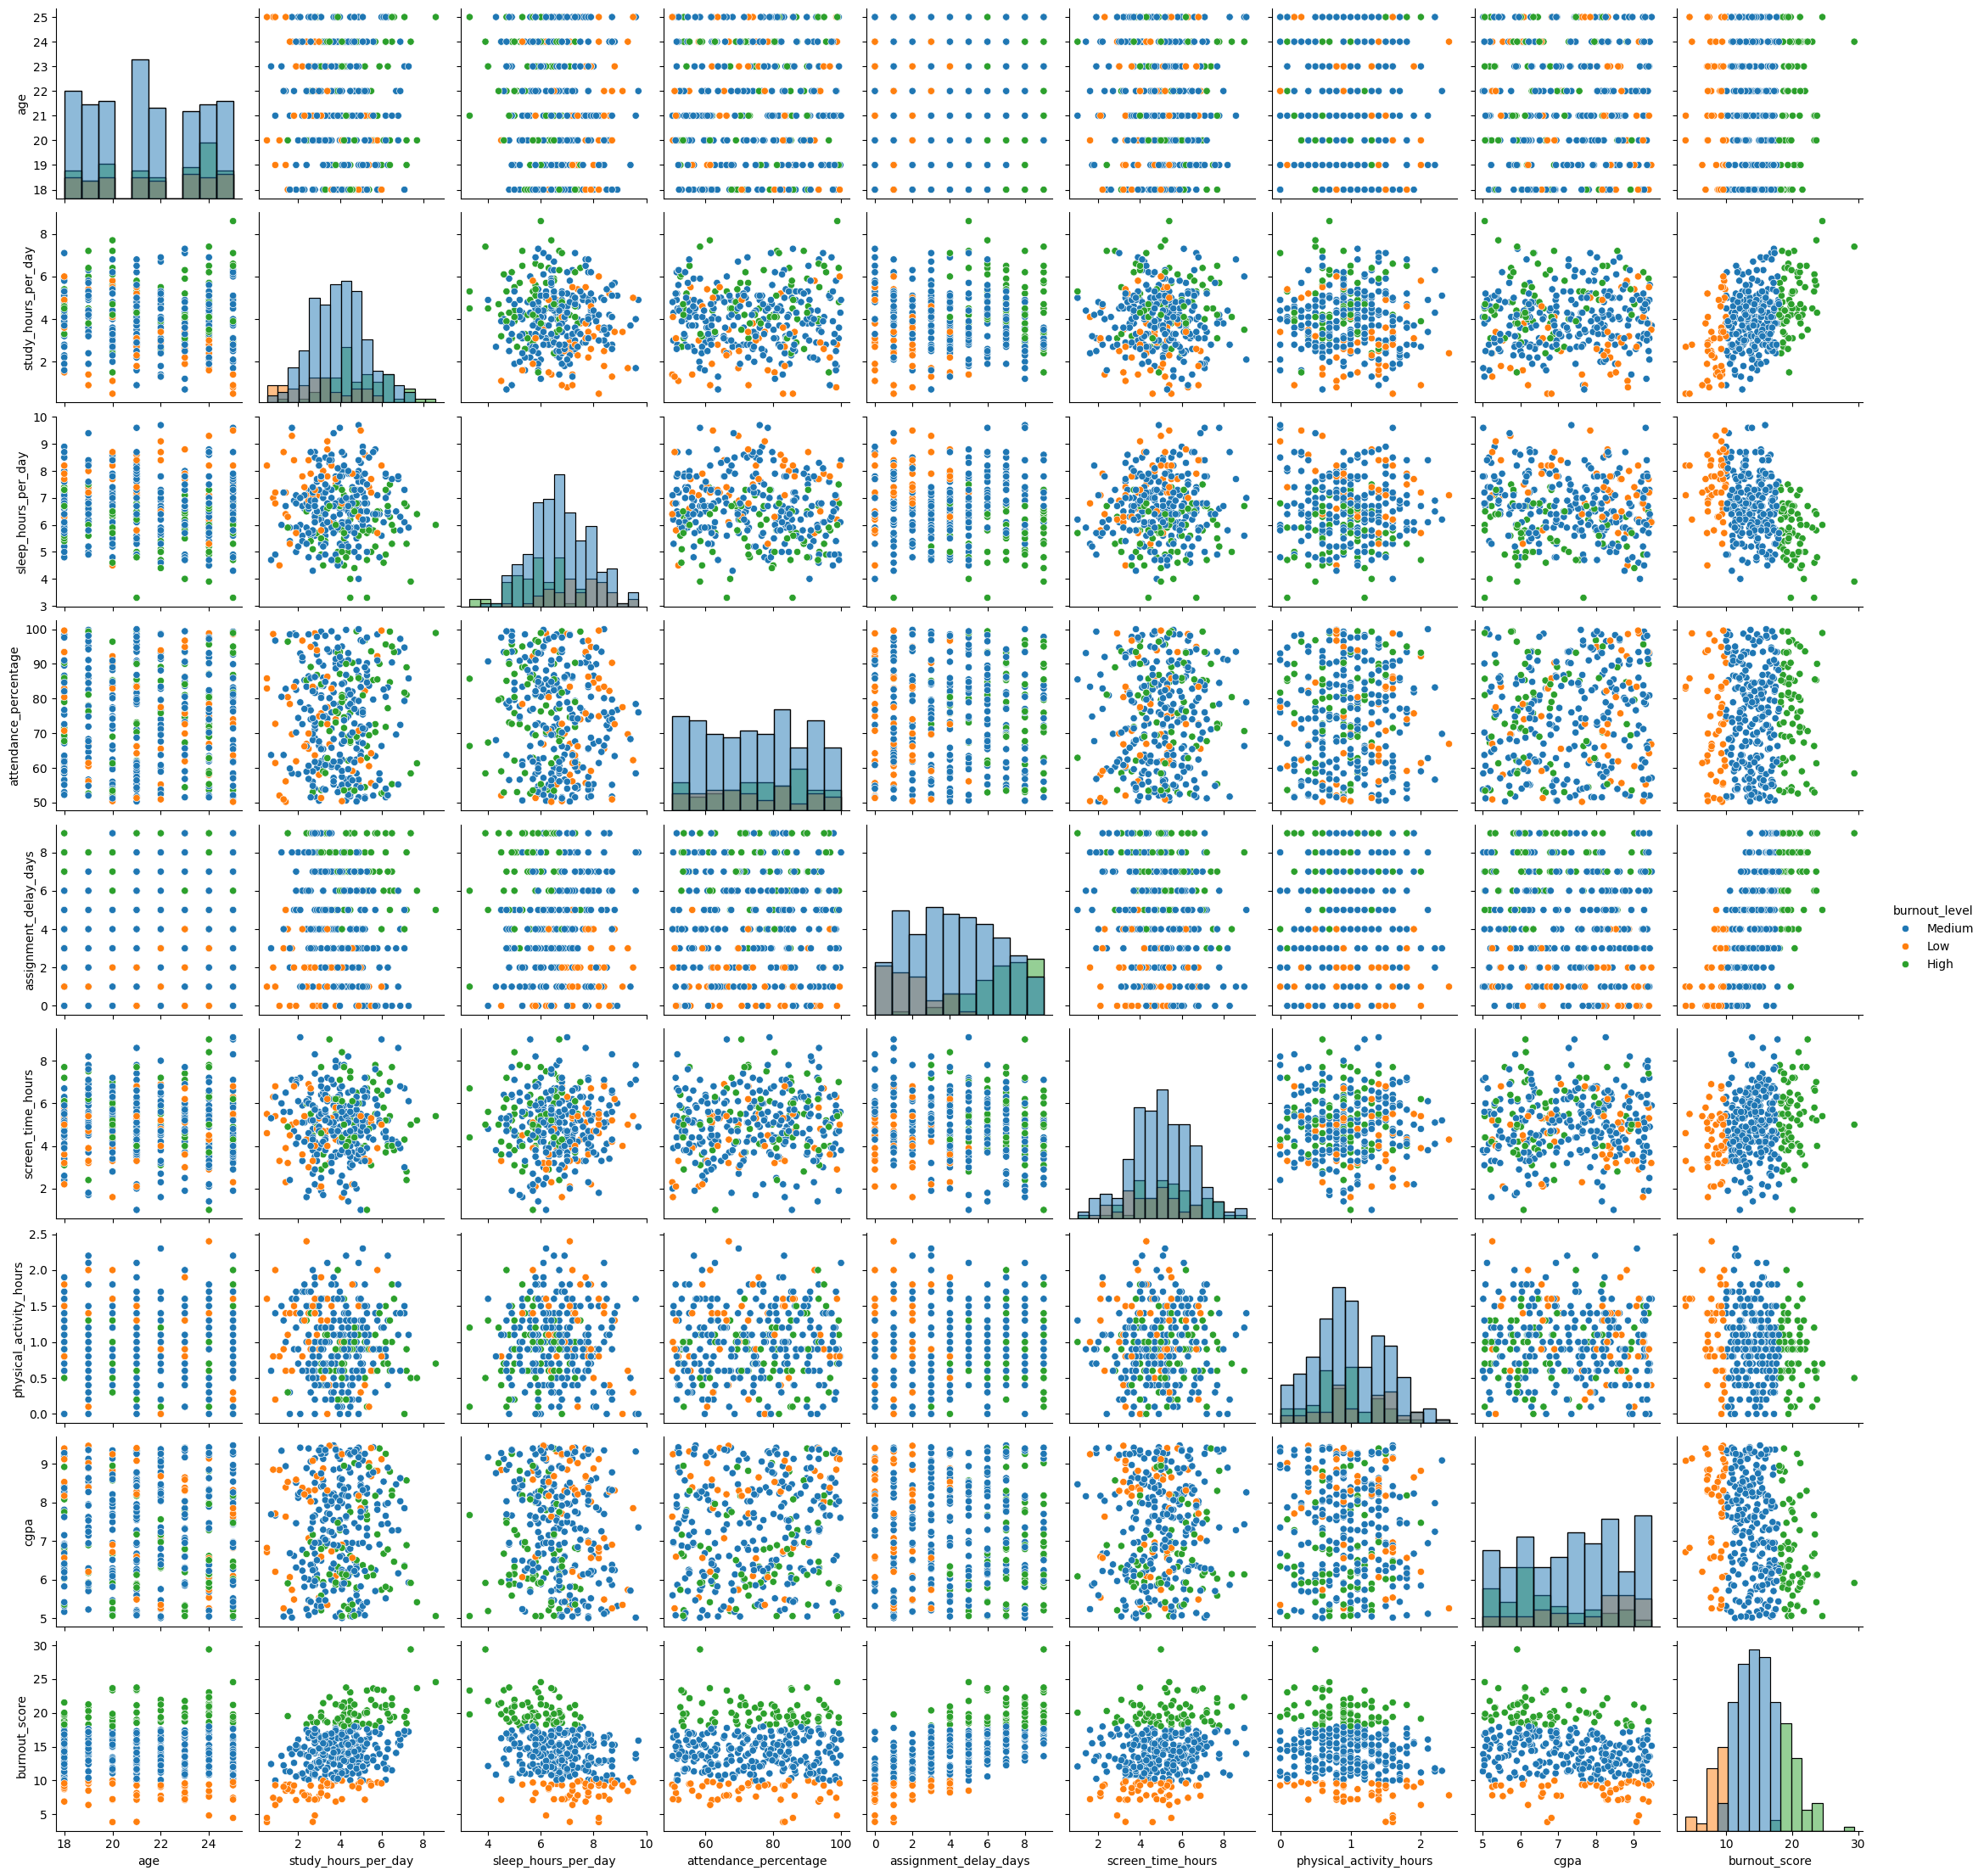

In [5]:
sns.pairplot(
    df,
    hue="burnout_level",
    diag_kind="hist"
)
plt.show()

In [6]:
df = df.drop("burnout_score", axis=1)

In [7]:
x = df.drop("burnout_level", axis=1)
y = df["burnout_level"]

In [8]:
x = pd.get_dummies(x, drop_first=True)

In [9]:
import os

os.makedirs("../data/processed", exist_ok=True)

processed_df = pd.concat([x, y], axis=1)
processed_df.to_csv("../data/processed/processed_data.csv", index=False)

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [11]:
import pandas as pd
feature_importance = pd.Series(
    model.feature_importances_,
    index=x.columns
).sort_values(ascending=False)
print(feature_importance)

NameError: name 'model' is not defined

Scaling Part

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)

print("Logistic Regression")
print(classification_report(y_test, lr.predict(x_test_scaled)))

Logistic Regression
              precision    recall  f1-score   support

        High       1.00      0.93      0.96        14
         Low       0.78      0.70      0.74        10
      Medium       0.92      0.96      0.94        46

    accuracy                           0.91        70
   macro avg       0.90      0.86      0.88        70
weighted avg       0.91      0.91      0.91        70



In [ ]:
from sklearn.metrics import accuracy_score
models = {
    "Random Forest": model,
    "Logistic Regression": lr,
    "SVM": svm,
    "KNN": knn,
    "Decision Tree": dt,
    "Naive Bayes": nb
}
for name, mdl in models.items():
    if name in ["Decision Tree","Random Forest"]:
        preds = mdl.predict(x_test)
    else:
        preds = mdl.predict(x_test_scaled)
    print(name, ":", accuracy_score(y_test, preds))

Random Forest : 0.7714285714285715
Logistic Regression : 0.9142857142857143
SVM : 0.8857142857142857
KNN : 0.7571428571428571
Decision Tree : 0.6285714285714286
Naive Bayes : 0.8285714285714286


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = final_model.predict(x_test_scaled)

print("Final Logistic Regression report")
print(classification_report(y_test, y_pred))

Final Logistic Regression report
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        14
         Low       0.71      1.00      0.83        10
      Medium       1.00      0.91      0.95        46

    accuracy                           0.94        70
   macro avg       0.90      0.97      0.93        70
weighted avg       0.96      0.94      0.95        70



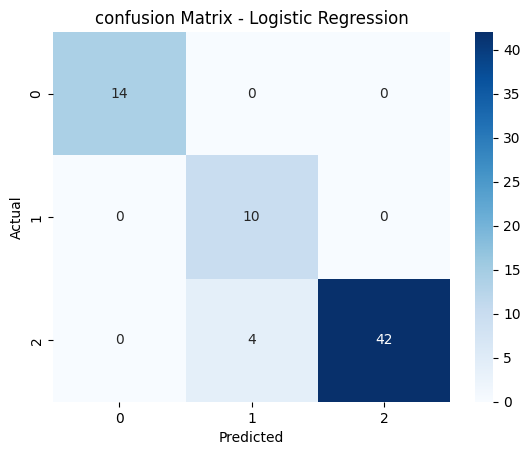

In [ ]:
cn = confusion_matrix(y_test, y_pred)
sns.heatmap(cn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
import pandas as pd

coef_df = pd.DataFrame({
    "feature" : x.columns,
    "coefficient" : final_model.coef_[0]
})

coef_df = coef_df.sort_values(by="coefficient", ascending=False)

print(coef_df)

                   feature  coefficient
4    assignment_delay_days     3.218640
1      study_hours_per_day     1.898426
5        screen_time_hours     1.363021
3    attendance_percentage     0.019903
8              gender_Male     0.005361
0                      age    -0.083825
6  physical_activity_hours    -0.654702
7                     cgpa    -1.388292
2      sleep_hours_per_day    -2.242787


In [ ]:
import joblib

joblib.dump(final_model, "../models/burnout_final_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [ ]:
sample = x_test_scaled[0].reshape(1, -1)
prediction = final_model.predict(sample)
print("Sample Prediction:", prediction)

Sample Prediction: ['Medium']


In [18]:
def academic_risk(row):
    score = 0   

    if row["cgpa"] < 6:
        score += 2
    elif row["cgpa"] < 7.5:
        score += 1

    if row["attendance_percentage"] < 60:
        score += 1

    if row["assignment_delay_days"] > 10:
        score += 1


    if score >= 3:
        return "High Risk"
    elif score == 2:
        return "Medium Risk"
    else:
        return "Low Risk"


df["academic_risk"] = df.apply(academic_risk, axis=1)

In [19]:
df["academic_risk"].value_counts()

academic_risk
Low Risk       253
Medium Risk     79
High Risk       18
Name: count, dtype: int64

In [20]:
x2 = df.drop(["burnout_level", "academic_risk"], axis = 1)
y2 = df["academic_risk"]

In [21]:
x2 = pd.get_dummies(x2, drop_first=True)

In [22]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(x2, y2,test_size=0.2,random_state=42,stratify=y2)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

In [26]:
academic_model = LogisticRegression(max_iter=1000)
academic_model.fit(X2_train_scaled, y2_train)

y2_pred = academic_model.predict(X2_test_scaled)

print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

   High Risk       0.67      0.50      0.57         4
    Low Risk       0.94      0.94      0.94        50
 Medium Risk       0.71      0.75      0.73        16

    accuracy                           0.87        70
   macro avg       0.77      0.73      0.75        70
weighted avg       0.87      0.87      0.87        70



In [28]:
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(academic_model, "../models/academic_model.pkl")
joblib.dump(scaler2, "../models/academic_scaler.pkl")
joblib.dump(X2_train.columns, "../models/academic_feature_columns.pkl")

['../models/academic_feature_columns.pkl']